# Stage 2: Predictor EDA

## Part 1: Data setup and structural checks

The Stage 2 predictor matrix and supporting outputs are loaded. Matrix dimensions, participant identifiers, domain composition, predictor manifest, imported data types and observed cardinality are checked before descriptive EDA. The age-18 outcome is not loaded in this notebook.

In [1]:
# 1: Set project paths and confirm required files

from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import chi2_contingency

working_directory = Path.cwd().resolve()

# Locate the project root from either the root directory or a notebook subdirectory.
project_root = next(
    (
        directory
        for directory in [working_directory, *working_directory.parents]
        if (
            directory
            / "data_derived"
            / "stage_2_predictor_construction"
        ).is_dir()
    ),
    None,
)

if project_root is None:
    raise FileNotFoundError(
        "The Stage 2 predictor-construction directory could not be located."
    )

stage_2_directory = (
    project_root
    / "data_derived"
    / "stage_2_predictor_construction"
)

required_files = [
    "stage_2_predictor_matrix.csv",
    "stage_2_predictor_missingness_summary.csv",
    "stage_2_predictor_coverage_summary.csv",
    "stage_2_predictor_sample_support.csv",
    "stage_2_variable_decision_register.csv",
    "stage_2_predictor_domain_summary.csv",
    "stage_2_final_predictor_manifest.csv",
]

file_check = {
    file_name: (stage_2_directory / file_name).is_file()
    for file_name in required_files
}

print("Project root located.")
print(
    "Stage 2 directory:",
    stage_2_directory.relative_to(project_root).as_posix(),
)
print(
    f"Required files found: "
    f"{sum(file_check.values())} of {len(required_files)}"
)

assert stage_2_directory.is_dir()
assert all(file_check.values())


Project root located.
Stage 2 directory: data_derived/stage_2_predictor_construction
Required files found: 7 of 7


In [2]:
# 2: Load the final Stage 2 predictor files

predictor_matrix = pd.read_csv(
    stage_2_directory / "stage_2_predictor_matrix.csv"
)
predictor_missingness_file = pd.read_csv(
    stage_2_directory / "stage_2_predictor_missingness_summary.csv"
)
predictor_coverage_file = pd.read_csv(
    stage_2_directory / "stage_2_predictor_coverage_summary.csv"
)
sample_support = pd.read_csv(
    stage_2_directory / "stage_2_predictor_sample_support.csv"
)
decision_register = pd.read_csv(
    stage_2_directory / "stage_2_variable_decision_register.csv",
    low_memory=False,
)
predictor_domain_summary = pd.read_csv(
    stage_2_directory / "stage_2_predictor_domain_summary.csv"
)
final_predictor_manifest = pd.read_csv(
    stage_2_directory / "stage_2_final_predictor_manifest.csv"
)

loaded_files = {
    "stage_2_predictor_matrix.csv": predictor_matrix,
    "stage_2_predictor_missingness_summary.csv": predictor_missingness_file,
    "stage_2_predictor_coverage_summary.csv": predictor_coverage_file,
    "stage_2_predictor_sample_support.csv": sample_support,
    "stage_2_variable_decision_register.csv": decision_register,
    "stage_2_predictor_domain_summary.csv": predictor_domain_summary,
    "stage_2_final_predictor_manifest.csv": final_predictor_manifest,
}

for file_name, data in loaded_files.items():
    print(
        f"{file_name}: "
        f"{data.shape[0]:,} rows × {data.shape[1]:,} columns"
    )


stage_2_predictor_matrix.csv: 9,767 rows × 70 columns
stage_2_predictor_missingness_summary.csv: 69 rows × 4 columns
stage_2_predictor_coverage_summary.csv: 36 rows × 3 columns
stage_2_predictor_sample_support.csv: 9,767 rows × 4 columns
stage_2_variable_decision_register.csv: 5,261 rows × 17 columns
stage_2_predictor_domain_summary.csv: 12 rows × 3 columns
stage_2_final_predictor_manifest.csv: 69 rows × 7 columns


In [3]:
# 3: Check the predictor specification

expected_participants = 9_767
expected_predictors = 69
expected_conceptual_domains = 11
expected_represented_domains = 10

predictor_names = predictor_matrix.columns.drop("NSID").tolist()
predictor_count = len(predictor_names)

assert predictor_matrix.shape == (
    expected_participants,
    expected_predictors + 1,
)
assert predictor_count == expected_predictors
assert final_predictor_manifest["Predictor"].is_unique
assert set(final_predictor_manifest["Predictor"]) == set(predictor_names)

# Count all reviewed domains separately from domains represented by at least one predictor.
conceptual_domains = predictor_domain_summary.loc[
    predictor_domain_summary["Predictor domain"].ne("Total")
].copy()
represented_domains = conceptual_domains.loc[
    conceptual_domains["Predictors"] > 0
].copy()

assert len(conceptual_domains) == expected_conceptual_domains
assert len(represented_domains) == expected_represented_domains
assert int(conceptual_domains["Predictors"].sum()) == expected_predictors
assert (
    predictor_domain_summary.loc[
        predictor_domain_summary["Predictor domain"].eq("Total"),
        "Predictors",
    ].iloc[0]
    == expected_predictors
)

outcome_columns = {
    "age18_outcome",
    "age18_outcome_code",
}
assert outcome_columns.isdisjoint(predictor_matrix.columns)

specified_predictors_to_check = [
    "non_english_home_language",
    "academic_self_concept_score",
    "school_exclusion_history_pretransition",
    "home_computer_access_pretransition",
    "family_future_study_discussion_frequency_pretransition",
    "peer_future_study_discussion_frequency_pretransition",
    "vocational_course_study_pretransition",
]
assert set(specified_predictors_to_check).issubset(predictor_names)

print(f"Participant rows: {len(predictor_matrix):,}")
print(f"Predictors: {predictor_count}")
print(f"Conceptual domains reviewed: {len(conceptual_domains)}")
print(f"Domains represented in the predictor matrix: {len(represented_domains)}")
print("Outcome columns loaded: 0")

print("\nPredictor composition by domain:")
display(conceptual_domains[["Predictor domain", "Predictors"]])

print("Specified predictors present:")
display(
    final_predictor_manifest.loc[
        final_predictor_manifest["Predictor"].isin(
            specified_predictors_to_check
        ),
        [
            "Predictor",
            "Predictor domain",
            "Non-missing",
            "Missing",
            "Missing percentage",
        ],
    ].sort_values("Predictor")
)


Participant rows: 9,767
Predictors: 69
Conceptual domains reviewed: 11
Domains represented in the predictor matrix: 10
Outcome columns loaded: 0

Predictor composition by domain:


,Predictor domain,Predictors
0,Demographic background,5
1,Family socioeconomic background,7
2,Prior attainment,0
3,"SEN, disability and health",8
4,Educational aspirations and post-16 plans,2
5,School experiences and engagement,9
6,Psychosocial characteristics,2
7,Experiences and behaviours,7
8,"Parental attitudes, support and engagement",16
9,Post-16 social influences and guidance,10


Specified predictors present:


,Predictor,Predictor domain,Non-missing,Missing,Missing percentage
31,academic_self_concept_score,Psychosocial characteristics,9172,595,6.09
57,family_future_study_discussion_frequency_pretr...,Post-16 social influences and guidance,9516,251,2.57
11,home_computer_access_pretransition,Family socioeconomic background,9434,333,3.41
4,non_english_home_language,Demographic background,9349,418,4.28
58,peer_future_study_discussion_frequency_pretran...,Post-16 social influences and guidance,9516,251,2.57
25,school_exclusion_history_pretransition,School experiences and engagement,9077,690,7.06
30,vocational_course_study_pretransition,School experiences and engagement,9445,322,3.30


In [4]:
# 4: Check NSID integrity

print(f"Rows: {len(predictor_matrix):,}")
print(f"Unique NSIDs: {predictor_matrix['NSID'].nunique():,}")
print(f"Missing NSIDs: {predictor_matrix['NSID'].isna().sum():,}")
print(f"Duplicate NSIDs: {predictor_matrix['NSID'].duplicated().sum():,}")
print(f"NSID data type: {predictor_matrix['NSID'].dtype}")

Rows: 9,767
Unique NSIDs: 9,767
Missing NSIDs: 0
Duplicate NSIDs: 0
NSID data type: str


In [5]:
# 5: Summarise imported predictor data types

predictor_dtypes = (
    predictor_matrix
    .drop(columns="NSID")
    .dtypes
    .astype(str)
    .value_counts()
)

print("Imported predictor data types:")
print(predictor_dtypes.to_string())

Imported predictor data types:
float64    65
str         4


In [6]:
# 6: Inspect string predictors

string_predictors = [
    variable
    for variable in predictor_matrix.columns.drop("NSID")
    if pd.api.types.is_string_dtype(predictor_matrix[variable])
]

print(f"String predictors: {len(string_predictors)}")

for variable in string_predictors:
    values = predictor_matrix[variable].dropna().unique()

    print(f"\n{variable}")
    print(f"Unique observed values: {len(values)}")
    print(f"First 10 values: {values[:10].tolist()}")
    print(f"Values not displayed: {max(0, len(values) - 10)}")

String predictors: 4

sex
Unique observed values: 2
First 10 values: ['Male', 'Female']
Values not displayed: 0

ethnicity
Unique observed values: 8
First 10 values: ['White', 'Pakistani', 'Indian', 'Bangladeshi', 'Black African', 'Other', 'Black Caribbean', 'Mixed']
Values not displayed: 0

english_first_or_main_language
Unique observed values: 2
First 10 values: ['Yes', 'No']
Values not displayed: 0

expected_post16_route
Unique observed values: 7
First 10 values: ['Work-based training or employment-training', 'Sixth-form college', 'Further-education college', 'School sixth form', 'Other or unspecified full-time education', 'Other, mixed or uncertain route', 'Full-time employment']
Values not displayed: 0


In [7]:
# 7: Summarise unique values in numeric predictors

numeric_predictors = [
    variable
    for variable in predictor_matrix.columns.drop("NSID")
    if pd.api.types.is_numeric_dtype(predictor_matrix[variable])
]

unique_counts = (
    predictor_matrix[numeric_predictors]
    .nunique(dropna=True)
    .sort_values()
)

numeric_cardinality = (
    unique_counts
    .rename("Unique observed values")
    .rename_axis("Predictor")
    .reset_index()
)

print(f"Predictors imported with numeric dtype: {len(numeric_predictors)}")
print(f"Two unique values: {(unique_counts == 2).sum()}")
print(f"Three to ten unique values: {unique_counts.between(3, 10).sum()}")
print(f"More than ten unique values: {(unique_counts > 10).sum()}")

display(numeric_cardinality.head(12))
print(f"Rows not displayed: {max(0, len(numeric_cardinality) - 12)}")


Predictors imported with numeric dtype: 65
Two unique values: 19
Three to ten unique values: 43
More than ten unique values: 3


,Predictor,Unique observed values
0,non_english_home_language,2
1,disability_benefit_receipt,2
2,current_statement_of_needs_pretransition,2
3,home_computer_access_pretransition,2
4,additional_parental_care_due_to_disability,2
5,vocational_course_study_pretransition,2
6,school_exclusion_history_pretransition,2
7,truancy_status_pretransition,2
8,any_school_change_by_wave3,2
9,bullying_experience_pretransition,2


Rows not displayed: 53


### Number of observed values

Numeric predictors are grouped by observed cardinality to distinguish binary and low-cardinality coded measures from higher-cardinality scores or derived variables. Counts are calculated directly from the 69-predictor matrix.

In [8]:
# 8: Inspect numeric predictors with more than ten observed values

higher_cardinality_predictors = unique_counts[unique_counts > 10].index

higher_cardinality_summary = pd.DataFrame({
    "Predictor": higher_cardinality_predictors,
    "Unique values": [
        predictor_matrix[variable].nunique(dropna=True)
        for variable in higher_cardinality_predictors
    ],
    "Minimum": [
        predictor_matrix[variable].min()
        for variable in higher_cardinality_predictors
    ],
    "Maximum": [
        predictor_matrix[variable].max()
        for variable in higher_cardinality_predictors
    ],
})

display(higher_cardinality_summary)

,Predictor,Unique values,Minimum,Maximum
0,young_person_ghq12_score,13,0.0,12.0
1,birth_month_position,28,-11.0,22.0
2,school_attitude_score,108,1.0,4.0


### Higher-cardinality numeric predictors

Numeric predictors with more than ten observed values are inspected for plausible ranges and score structure. This is a value-quality check; no predictor is removed solely because it has higher cardinality.


In [9]:
# 9: Check the form of higher-cardinality numeric predictors

rows = []

for variable in higher_cardinality_predictors:
    observed = predictor_matrix[variable].dropna()

    rows.append({
        "Predictor": variable,
        "Non-missing": len(observed),
        "Missing": predictor_matrix[variable].isna().sum(),
        "All observed values are integers": (observed % 1 == 0).all(),
        "Minimum": observed.min(),
        "25th percentile": observed.quantile(0.25),
        "Median": observed.median(),
        "75th percentile": observed.quantile(0.75),
        "Maximum": observed.max(),
    })

display(pd.DataFrame(rows))

,Predictor,Non-missing,Missing,All observed values are integers,Minimum,25th percentile,Median,75th percentile,Maximum
0,young_person_ghq12_score,9089,678,True,0.0,0.00,1.000000,2.000000,12.0
1,birth_month_position,9524,243,True,-11.0,3.00,6.000000,9.000000,22.0
2,school_attitude_score,9511,256,False,1.0,2.75,3.083333,3.333333,4.0


### Distribution of higher-cardinality predictors

Summary statistics are used to check the observed range, centre and spread of higher-cardinality predictors. Integer status is also reported so that constructed scores can be distinguished from coded categories and derived integer variables.


In [10]:
# 10: Inspect the birth-month-position distribution

birth_month_counts = (
    predictor_matrix["birth_month_position"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("Birth month position")
    .reset_index(name="Participants")
)

print("Lowest seven observed positions:")
display(birth_month_counts.head(7))

print("Highest seven observed positions:")
display(birth_month_counts.tail(7))

print(f"Rows not displayed: {max(0, len(birth_month_counts) - 14)}")

Lowest seven observed positions:


,Birth month position,Participants
0,-11.0,1
1,-9.0,1
2,-8.0,1
3,-7.0,1
4,-4.0,3
5,-3.0,6
6,-2.0,3


Highest seven observed positions:


,Birth month position,Participants
22,14.0,1
23,15.0,2
24,17.0,1
25,18.0,1
26,20.0,2
27,22.0,1
28,NaN,243


Rows not displayed: 15


In [11]:
# 11: Check birth-month positions outside the central 0–11 range

outside_central_range = predictor_matrix.loc[
    predictor_matrix["birth_month_position"].notna()
    & ~predictor_matrix["birth_month_position"].between(0, 11),
    ["NSID", "birth_month_position"]
].sort_values("birth_month_position")

# Keep NSID for in-memory checking but report only aggregate values.
print(f"Participants outside the 0–11 range: {len(outside_central_range):,}")
print("\nValue counts:")
print(
    outside_central_range["birth_month_position"]
    .value_counts()
    .sort_index()
    .to_string()
)


Participants outside the 0–11 range: 48

Value counts:
birth_month_position
-11.0     1
-9.0      1
-8.0      1
-7.0      1
-4.0      3
-3.0      6
-2.0      3
-1.0     12
 12.0    11
 13.0     1
 14.0     1
 15.0     2
 17.0     1
 18.0     1
 20.0     2
 22.0     1


In [12]:
# 12: Inspect birth-month construction records

birth_month_records = decision_register.loc[
    decision_register["Variable"].isin(["DobyearYP", "DobmonthYP"]),
    [
        "Variable",
        "Variable label",
        "Review outcome",
        "Decision reason",
        "Review notes",
    ],
]

display(birth_month_records)

,Variable,Variable label,Review outcome,Decision reason,Review notes
6,DobyearYP,Edited: Year of birth of YP,Retain as construction source,Provides birth-timing information. Birth year ...,Used jointly with DobmonthYP to construct the ...
7,DobmonthYP,Edited: Month of birth of YP,Retain as construction source,Provides birth-timing information. Birth year ...,Used jointly with DobyearYP to construct the p...


### Birth-month construction review

`birth_month_position` is inspected separately because its derived scale can extend outside the central 0–11 month window. The source-variable records in the Stage 2 decision register are used to confirm that outlying positions arise from the documented birth-year and birth-month construction. EDA does not recode or remove these records without a source-based reason.


## Part 2: Missingness

Predictor-level missingness and participant-level coverage are examined before modelling. The Wave 4 boost participants are reviewed separately because they lack Wave 1 source records and therefore have structural gaps across many pre-transition predictors. Missing values are described only; no imputation or participant exclusion is undertaken in this notebook.


In [13]:
# 1: Summarise predictor-level missingness

predictor_data = predictor_matrix.drop(columns="NSID")

predictor_missingness = pd.DataFrame(
    {
        "Predictor": predictor_data.columns,
        "Non-missing": predictor_data.notna().sum().values,
        "Missing": predictor_data.isna().sum().values,
    }
)

predictor_missingness["Missing percentage"] = (
    predictor_missingness["Missing"]
    / len(predictor_matrix)
    * 100
).round(2)

predictor_missingness = (
    predictor_missingness
    .sort_values(
        ["Missing percentage", "Predictor"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

missingness_check = predictor_missingness.merge(
    predictor_missingness_file,
    on="Predictor",
    how="outer",
    suffixes=("_calculated", "_saved"),
    indicator=True,
)

assert len(missingness_check) == predictor_count
assert (missingness_check["_merge"] == "both").all()
assert (
    missingness_check["Non-missing_calculated"]
    == missingness_check["Non-missing_saved"]
).all()
assert (
    missingness_check["Missing_calculated"]
    == missingness_check["Missing_saved"]
).all()
assert np.allclose(
    missingness_check["Missing percentage_calculated"],
    missingness_check["Missing percentage_saved"],
)

print("Predictors with the highest missingness:")
display(predictor_missingness.head(10))

print(f"Rows not displayed: {max(0, len(predictor_missingness) - 10)}")
print(
    "\nPredictors with no missing values:",
    (predictor_missingness["Missing"] == 0).sum(),
)
print(
    "Predictors with more than 50% missing:",
    (predictor_missingness["Missing percentage"] > 50).sum(),
)
print("Saved missingness summary matches calculated values: True")


Predictors with the highest missingness:


,Predictor,Non-missing,Missing,Missing percentage
0,parental_autonomy_support_score_pretransition,8622,1145,11.72
1,household_income_band,8771,996,10.20
2,parental_higher_education_expectation_pretrans...,8874,893,9.14
3,teacher_listening_fair_treatment_score_pretran...,8962,805,8.24
4,parent_communication_frequency_score_pretransi...,8996,771,7.89
5,school_contact_about_behaviour_ever_pretransition,9019,748,7.66
6,recent_police_contact_pretransition,9022,745,7.63
7,family_nssec_code,9040,727,7.44
8,learning_mentor_engagement_profile_pretransition,9073,694,7.11
9,school_exclusion_history_pretransition,9077,690,7.06


Rows not displayed: 59

Predictors with no missing values: 0
Predictors with more than 50% missing: 0
Saved missingness summary matches calculated values: True


In [14]:
# 2: Check the lowest predictor-level missingness

lowest_missingness = predictor_missingness.sort_values(
    "Missing", ascending=True
).reset_index(drop=True)

display(lowest_missingness.head(10))

print(f"Rows not displayed: {max(0, len(lowest_missingness) - 10)}")
print(
    f"\nPredictors missing for exactly 243 participants: "
    f"{(lowest_missingness['Missing'] == 243).sum()}"
)
print(f"Minimum missing count: {lowest_missingness['Missing'].min():,}")

,Predictor,Non-missing,Missing,Missing percentage
0,ethnicity,9763,4,0.04
1,sex,9758,9,0.09
2,sen_status_pretransition,9642,125,1.28
3,current_statement_of_needs_pretransition,9625,142,1.45
4,birth_month_position,9524,243,2.49
5,independent_school_at_sampling_stage,9524,243,2.49
6,working_parent_or_guardian_count,9523,244,2.50
7,young_person_caring_responsibility_pretransition,9521,246,2.52
8,housing_tenure,9521,246,2.52
9,urban_rural_settlement_type_pretransition,9520,247,2.53


Rows not displayed: 59

Predictors missing for exactly 243 participants: 2
Minimum missing count: 4


### Predictor-level missingness

Missingness is recalculated from the 69-predictor matrix and compared with the saved Stage 2 missingness summary. The Wave 1 home-language measure and the two-item academic self-concept score are included in these checks.

In [15]:
# 3: Check participant-level predictor counts

calculated_support = predictor_matrix[["NSID"]].copy()
calculated_support["predictors_available_calculated"] = (
    predictor_matrix
    .drop(columns="NSID")
    .notna()
    .sum(axis=1)
)

support_check = sample_support[
    ["NSID", "predictors_available"]
].merge(
    calculated_support,
    on="NSID",
    how="outer",
    indicator=True,
)

count_difference = (
    support_check["predictors_available"]
    != support_check["predictors_available_calculated"]
)

print(
    "NSID mismatches:",
    (support_check["_merge"] != "both").sum()
)
print("Predictor-count differences:", count_difference.sum())

assert (support_check["_merge"] == "both").all()
assert not count_difference.any()


NSID mismatches: 0
Predictor-count differences: 0


In [16]:
# 4: Summarise participant-level predictor availability

availability_summary = sample_support["predictors_available"].describe(
    percentiles=[0.25, 0.50, 0.75]
)

calculated_coverage = (
    sample_support["predictors_available"]
    .value_counts()
    .sort_index()
    .rename("Participants")
    .rename_axis("Predictors available")
    .reset_index()
)
calculated_coverage["Percentage of full sample"] = (
    calculated_coverage["Participants"]
    / len(sample_support)
    * 100
).round(2)

coverage_check = calculated_coverage.merge(
    predictor_coverage_file,
    on="Predictors available",
    how="outer",
    suffixes=("_calculated", "_saved"),
    indicator=True,
)

assert (coverage_check["_merge"] == "both").all()
assert (
    coverage_check["Participants_calculated"]
    == coverage_check["Participants_saved"]
).all()
assert np.allclose(
    coverage_check["Percentage of full sample_calculated"],
    coverage_check["Percentage of full sample_saved"],
)

print("Participant-level predictor availability:")
print(availability_summary.to_string())

print(
    "\nParticipants with five or fewer predictors:",
    int(sample_support["five_or_fewer_predictors_available"].sum()),
)
print(
    f"Participants with all {predictor_count} predictors:",
    int((sample_support["predictors_available"] == predictor_count).sum()),
)
print(
    "Participants with at least 65 predictors:",
    int((sample_support["predictors_available"] >= 65).sum()),
)
print("Saved coverage summary matches calculated values: True")


Participant-level predictor availability:
count    9767.000000
mean       66.184089
std        10.284948
min         1.000000
25%        68.000000
50%        69.000000
75%        69.000000
max        69.000000

Participants with five or fewer predictors: 243
Participants with all 69 predictors: 5203
Participants with at least 65 predictors: 8866
Saved coverage summary matches calculated values: True


### Participant-level predictor coverage

Participant-level coverage is summarised from the final predictor set. Complete-case coverage is not used to define the modelling sample at this stage. The low-coverage group is examined separately because structural absence of earlier-wave measurement is different from ordinary item non-response.


In [17]:
# 5: Check predictor coverage by Wave 1 source-record status

coverage_by_wave1 = (
    sample_support
    .groupby("wave_1_source_record_present")["predictors_available"]
    .agg(["count", "min", "median", "max"])
)

limited_coverage_check = pd.crosstab(
    sample_support["wave_1_source_record_present"],
    sample_support["five_or_fewer_predictors_available"]
)

print("Predictor availability by Wave 1 source-record status:")
display(coverage_by_wave1)

print("Participants with five or fewer predictors:")
display(limited_coverage_check)

Predictor availability by Wave 1 source-record status:


,count,min,median,max
wave_1_source_record_present,,,,
False,243,1,4.0,4
True,9524,29,69.0,69


Participants with five or fewer predictors:


five_or_fewer_predictors_available,False,True
wave_1_source_record_present,,
False,0,243
True,9524,0


### Predictor coverage by Wave 1 source-record status

Coverage is compared by Wave 1 source-record status to determine whether very low predictor availability is concentrated in the boost sample. Minimum, median and maximum availability are calculated from the 69-predictor matrix.

In [18]:
# 6: Summarise common participant-level missingness patterns

predictor_columns = predictor_matrix.columns.drop("NSID")
missing_flags = predictor_matrix[predictor_columns].isna()

# Record the set of missing predictors for each participant so recurring patterns can be counted.
participant_patterns = pd.DataFrame({
    "Missing predictors": missing_flags.apply(
        lambda row: tuple(predictor_columns[row]), axis=1
    ),
    "Wave 1 source record absent": (
        ~sample_support
        .set_index("NSID")
        .loc[predictor_matrix["NSID"], "wave_1_source_record_present"]
        .to_numpy()
    ),
})

pattern_summary = (
    participant_patterns
    .groupby("Missing predictors")
    .agg(
        Participants=("Missing predictors", "size"),
        Wave_1_source_record_absent=("Wave 1 source record absent", "sum"),
    )
    .reset_index()
)

pattern_summary["Missing predictor count"] = (
    pattern_summary["Missing predictors"].apply(len)
)

pattern_summary = pattern_summary.sort_values(
    "Participants", ascending=False
).reset_index(drop=True)

display_table = pattern_summary.head(10).copy()
display_table["Missing predictors"] = display_table["Missing predictors"].apply(
    lambda values: ", ".join(values) if values else "None"
)

display(display_table)

print(f"Unique missingness patterns: {len(pattern_summary):,}")
print(f"Patterns not displayed: {max(0, len(pattern_summary) - 10):,}")

,Missing predictors,Participants,Wave_1_source_record_absent,Missing predictor count
0,None,5203,0,0
1,household_income_band,279,0,1
2,parental_higher_education_expectation_pretrans...,248,0,1
3,parental_autonomy_support_score_pretransition,227,0,1
4,learning_mentor_engagement_profile_pretransition,214,0,1
5,family_nssec_code,200,0,1
6,"birth_month_position, english_first_or_main_la...",197,197,65
7,teacher_listening_fair_treatment_score_pretran...,148,0,1
8,"school_exclusion_history_pretransition, recent...",96,0,3
9,young_person_ghq12_score,82,0,1


Unique missingness patterns: 1,100
Patterns not displayed: 1,090


### Missingness patterns

Participant-level missingness patterns are summarised to distinguish isolated item non-response from blocks of predictors missing together. Patterns concentrated among participants without a Wave 1 source record are treated as structural coverage differences rather than evidence that individual predictor values should be imputed at this stage.


In [19]:
# 7: Check predictors available for boost-sample participants

boost_ids = sample_support.loc[
    ~sample_support["wave_1_source_record_present"],
    "NSID",
]

boost_matrix = (
    predictor_matrix
    .loc[predictor_matrix["NSID"].isin(boost_ids)]
    .drop(columns="NSID")
)

boost_predictor_availability = (
    boost_matrix.notna().sum()
    .loc[lambda values: values > 0]
    .sort_values(ascending=False)
    .rename_axis("Predictor")
    .reset_index(name="Participants")
)

boost_predictor_availability["Percentage"] = (
    boost_predictor_availability["Participants"]
    / len(boost_matrix)
    * 100
).round(2)

print("Boost-sample participants:", len(boost_matrix))
display(boost_predictor_availability)

print(
    "Predictors available for at least one boost-sample participant:",
    len(boost_predictor_availability),
)

Boost-sample participants: 243


,Predictor,Participants,Percentage
0,ethnicity,241,99.18
1,sex,237,97.53
2,sen_status_pretransition,204,83.95
3,current_statement_of_needs_pretransition,204,83.95


Predictors available for at least one boost-sample participant: 4


### Wave 4 boost-sample coverage

Predictors observed for the Wave 4 boost sample are listed directly from the Stage 2 matrix. Home language uses Wave 1 information only, so the observed boost-sample coverage is determined from the saved predictor values.

In [20]:
# 8: Summarise missingness among participants with a Wave 1 source record

wave1_support = sample_support.loc[
    sample_support["wave_1_source_record_present"]
].copy()

wave1_support["predictors_missing"] = (
    predictor_count - wave1_support["predictors_available"]
)

print("Missing predictors among participants with a Wave 1 source record:")
print(wave1_support["predictors_missing"].describe().to_string())

print("\nMost common missing-predictor counts:")
print(
    wave1_support["predictors_missing"]
    .value_counts()
    .sort_index()
    .head(10)
    .to_string()
)


Missing predictors among participants with a Wave 1 source record:
count    9524.000000
mean        1.220286
std         2.474056
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max        40.000000

Most common missing-predictor counts:
predictors_missing
0    5203
1    2147
2     795
3     455
4     266
5     158
6     122
7      94
8      86
9      55


### Missingness among participants with a Wave 1 source record

Missingness among participants with a Wave 1 record is summarised separately from the structural boost-sample pattern. This shows the extent of ordinary item-level missingness within the group that has access to the main early-wave predictor sources.


In [21]:
# 9: Check participants with higher missingness

higher_missingness = wave1_support.loc[
    wave1_support["predictors_missing"] >= 10,
    ["NSID", "predictors_available", "predictors_missing"]
].sort_values("predictors_missing", ascending=False)

higher_missingness_distribution = (
    higher_missingness["predictors_missing"]
    .value_counts()
    .sort_index(ascending=False)
    .rename_axis("Predictors missing")
    .reset_index(name="Participants")
)

print(
    "Participants with 10 or more missing predictors:",
    len(higher_missingness),
)
display(higher_missingness_distribution.head(10))
print(
    f"Rows not displayed: "
    f"{max(0, len(higher_missingness_distribution) - 10)}"
)


Participants with 10 or more missing predictors: 143


,Predictors missing,Participants
0,40,1
1,39,2
2,35,1
3,31,1
4,28,1
5,26,1
6,25,2
7,24,1
8,23,7
9,22,3


Rows not displayed: 12


In [22]:
# 10: Check missing predictors among participants with higher missingness

higher_missingness_matrix = predictor_matrix.loc[
    predictor_matrix["NSID"].isin(higher_missingness["NSID"]),
    predictor_columns
]

higher_missingness_predictors = (
    higher_missingness_matrix
    .isna()
    .sum()
    .sort_values(ascending=False)
    .rename_axis("Predictor")
    .reset_index(name="Participants missing")
)

higher_missingness_predictors["Percentage"] = (
    higher_missingness_predictors["Participants missing"]
    / len(higher_missingness_matrix)
    * 100
).round(2)

display(higher_missingness_predictors.head(10))

print(
    f"Rows not displayed: "
    f"{max(0, len(higher_missingness_predictors) - 10)}"
)

,Predictor,Participants missing,Percentage
0,parental_autonomy_support_score_pretransition,102,71.33
1,parent_relationship_quality_score_pretransition,97,67.83
2,parent_communication_frequency_score_pretransi...,96,67.13
3,academic_self_concept_score,95,66.43
4,parent_school_day_discussion_frequency_pretran...,94,65.73
5,school_night_curfew_pretransition,93,65.03
6,parental_knowledge_of_evening_whereabouts_pret...,90,62.94
7,teacher_listening_fair_treatment_score_pretran...,65,45.45
8,young_person_ghq12_score,61,42.66
9,recent_police_contact_pretransition,58,40.56


Rows not displayed: 59


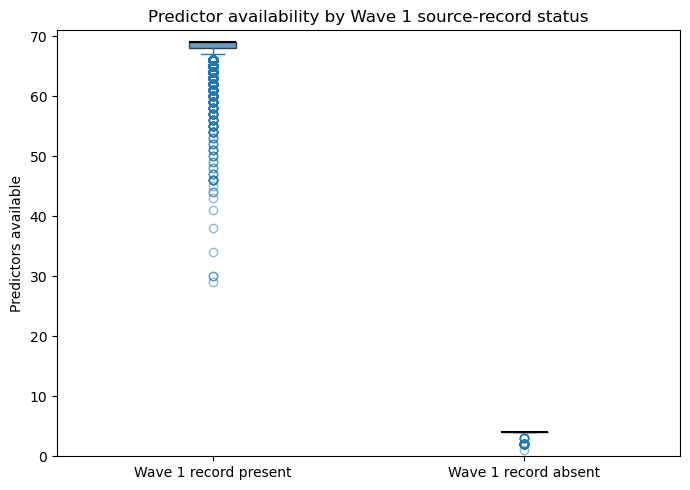

In [23]:
# 11: Plot predictor availability by Wave 1 source-record status

wave1_available = sample_support.loc[
    sample_support["wave_1_source_record_present"],
    "predictors_available",
]

wave1_absent = sample_support.loc[
    ~sample_support["wave_1_source_record_present"],
    "predictors_available",
]

plt.figure(figsize=(7, 5))
plt.boxplot(
    [wave1_available, wave1_absent],
    tick_labels=["Wave 1 record present", "Wave 1 record absent"],
    patch_artist=True,
    boxprops={"facecolor": "tab:blue", "alpha": 0.70},
    medianprops={"color": "black", "linewidth": 1.5},
    whiskerprops={"color": "tab:blue"},
    capprops={"color": "tab:blue"},
    flierprops={"markeredgecolor": "tab:blue", "alpha": 0.50},
)
plt.ylabel("Predictors available")
plt.title("Predictor availability by Wave 1 source-record status")
plt.ylim(0, predictor_count + 2)
plt.tight_layout()
plt.show()


### Predictor availability by Wave 1 source-record status

The boxplot provides a visual comparison of final predictor coverage between participants with and without a Wave 1 source record. It is used to show the structural separation in measurement coverage, not to make the modelling-sample decision within EDA.


## Part 3: Predictor distributions and value checks

All 69 final predictors are examined for unusable or implausibly coded values before modelling. Checks cover entirely missing, constant and exactly duplicated columns; category frequencies for low-cardinality predictors; numeric ranges; non-integer, negative and infinite values; and selected higher-cardinality distributions. These are quality-control checks rather than outcome-informed feature selection.


In [24]:
# 1: Check entirely missing and constant predictors

observed_unique_counts = (
    predictor_matrix
    .drop(columns="NSID")
    .nunique(dropna=True)
)

entirely_missing = observed_unique_counts[
    observed_unique_counts == 0
].index.tolist()

constant_predictors = observed_unique_counts[
    observed_unique_counts == 1
].index.tolist()

print(f"Entirely missing predictors: {len(entirely_missing)}")
print(f"Constant predictors: {len(constant_predictors)}")

if entirely_missing:
    print("\nEntirely missing:")
    print(entirely_missing[:15])
    print(f"Not displayed: {max(0, len(entirely_missing) - 15)}")

if constant_predictors:
    print("\nConstant predictors:")
    print(constant_predictors[:15])
    print(f"Not displayed: {max(0, len(constant_predictors) - 15)}")

Entirely missing predictors: 0
Constant predictors: 0


### Entirely missing and constant predictors

The final matrix is checked for predictors with no observed information or no observed variation. Either result would indicate a construction or consolidation problem requiring review before modelling.


In [25]:
# 2: Check exact duplicate predictors

predictor_data = predictor_matrix.drop(columns="NSID")
duplicate_pairs = []

for position, variable in enumerate(predictor_data.columns):
    for comparison in predictor_data.columns[position + 1:]:
        if predictor_data[variable].equals(predictor_data[comparison]):
            duplicate_pairs.append((variable, comparison))

print(f"Exact duplicate predictor pairs: {len(duplicate_pairs)}")

if duplicate_pairs:
    display(
        pd.DataFrame(
            duplicate_pairs[:15],
            columns=["Predictor 1", "Predictor 2"]
        )
    )
    print(f"Pairs not displayed: {max(0, len(duplicate_pairs) - 15)}")

Exact duplicate predictor pairs: 0


### Exact duplicate predictors

Exact duplicate columns are checked across the final predictor matrix. An exact match would trigger review of the underlying construction and provenance rather than automatic deletion based only on column names.


In [26]:
# 3: Check the least frequent observed categories

low_cardinality_predictors = observed_unique_counts[
    observed_unique_counts <= 10
].index

category_rows = []

for variable in low_cardinality_predictors:
    counts = predictor_matrix[variable].value_counts(dropna=True)

    for value, count in counts.items():
        category_rows.append({
            "Predictor": variable,
            "Value": value,
            "Participants": count,
            "Percentage of observed values": round(
                count / counts.sum() * 100, 2
            ),
        })

category_support = pd.DataFrame(category_rows).sort_values(
    ["Participants", "Predictor"]
).reset_index(drop=True)

display(category_support.head(15))

print(f"Category rows not displayed: {max(0, len(category_support) - 15):,}")

,Predictor,Value,Participants,Percentage of observed values
0,academic_self_concept_score,1.0,7,0.08
1,parent_relationship_quality_score_pretransition,0.5,13,0.14
2,parent_relationship_quality_score_pretransition,0.0,19,0.21
3,housing_tenure,3.0,31,0.33
4,academic_self_concept_score,1.5,32,0.35
5,teacher_guidance_frequency_index_pretransition,4.0,32,0.34
6,young_person_general_health,4.0,37,0.39
7,household_income_band,1.0,47,0.54
8,housing_tenure,8.0,47,0.49
9,housing_tenure,7.0,53,0.56


Category rows not displayed: 258


### Rare predictor categories

Low-cardinality predictors are screened for infrequently observed values. Small categories are retained at this stage; their treatment, if required, must be decided after the modelling sample and training data are defined.


In [27]:
# 4: Summarise predictors with categories below 1%

categories_below_one_percent = category_support.loc[
    category_support["Percentage of observed values"] < 1
]

category_below_one_percent_summary = (
    categories_below_one_percent
    .groupby("Predictor")
    .agg(
        Categories_below_1_percent=("Value", "count"),
        Smallest_category=("Participants", "min"),
    )
    .sort_values(
        ["Categories_below_1_percent", "Smallest_category"],
        ascending=[False, True]
    )
    .reset_index()
)

print(
    "Predictors with at least one category below 1%:",
    len(category_below_one_percent_summary)
)

display(category_below_one_percent_summary.head(15))

print(
    f"Rows not displayed: "
    f"{max(0, len(category_below_one_percent_summary) - 15)}"
)


Predictors with at least one category below 1%: 9


,Predictor,Categories_below_1_percent,Smallest_category
0,housing_tenure,3,31
1,academic_self_concept_score,2,7
2,parent_relationship_quality_score_pretransition,2,13
3,teacher_guidance_frequency_index_pretransition,2,32
4,teacher_listening_fair_treatment_score_pretran...,2,54
5,young_person_general_health,1,37
6,household_income_band,1,47
7,family_composition,1,85
8,careers_advice_service_guidance_frequency_pret...,1,86


Rows not displayed: 0


### Predictors with infrequent values

A 1% threshold is used only as a descriptive screen for uncommon observed values. It is not a predictor-removal rule. Training-sample support and substantive meaning are considered later when preprocessing is specified.


In [28]:
# 5: Inspect predictors with categories below 1%

below_one_percent_value_rows = []

for variable in category_below_one_percent_summary["Predictor"]:
    observed = predictor_matrix[variable].dropna()

    variable_below_one_percent = categories_below_one_percent.loc[
        categories_below_one_percent["Predictor"].eq(variable)
    ].sort_values("Participants")

    category_text = "; ".join(
        f"{row['Value']} ({row['Participants']}, "
        f"{row['Percentage of observed values']:.2f}%)"
        for _, row in variable_below_one_percent.iterrows()
    )

    below_one_percent_value_rows.append({
        "Predictor": variable,
        "Unique observed values": observed.nunique(),
        "Minimum": observed.min(),
        "Maximum": observed.max(),
        "Categories below 1%": category_text,
    })

below_one_percent_value_overview = pd.DataFrame(
    below_one_percent_value_rows
)

display(below_one_percent_value_overview)


,Predictor,Unique observed values,Minimum,Maximum,Categories below 1%
0,housing_tenure,8,1.0,8.0,"3.0 (31, 0.33%); 8.0 (47, 0.49%); 7.0 (53, 0.56%)"
1,academic_self_concept_score,9,1.0,5.0,"1.0 (7, 0.08%); 1.5 (32, 0.35%)"
2,parent_relationship_quality_score_pretransition,7,0.0,3.0,"0.5 (13, 0.14%); 0.0 (19, 0.21%)"
3,teacher_guidance_frequency_index_pretransition,9,0.0,4.0,"4.0 (32, 0.34%); 3.5 (53, 0.56%)"
4,teacher_listening_fair_treatment_score_pretran...,9,0.0,4.0,"0.0 (54, 0.60%); 0.5 (56, 0.62%)"
5,young_person_general_health,4,1.0,4.0,"4.0 (37, 0.39%)"
6,household_income_band,9,1.0,9.0,"1.0 (47, 0.54%)"
7,family_composition,5,1.0,5.0,"5.0 (85, 0.89%)"
8,careers_advice_service_guidance_frequency_pret...,5,0.0,4.0,"4.0 (86, 0.92%)"


### Infrequent predictor values

The specific values below the 1% descriptive threshold are displayed so that genuinely rare substantive categories can be distinguished from unusual codes or construction problems.


In [29]:
# 6: Inspect string predictor distributions

for variable in string_predictors:
    distribution = (
        predictor_matrix[variable]
        .value_counts(dropna=False)
        .rename_axis("Value")
        .reset_index(name="Participants")
    )

    distribution["Percentage of participants"] = (
        distribution["Participants"]
        / len(predictor_matrix)
        * 100
    ).round(2)

    print(f"\n{variable}")
    display(distribution)



sex


,Value,Participants,Percentage of participants
0,Female,4979,50.98
1,Male,4779,48.93
2,NaN,9,0.09



ethnicity


,Value,Participants,Percentage of participants
0,White,6636,67.94
1,Indian,689,7.05
2,Pakistani,557,5.70
3,Mixed,473,4.84
4,Bangladeshi,439,4.49
5,Black African,366,3.75
6,Black Caribbean,361,3.70
7,Other,242,2.48
8,NaN,4,0.04



english_first_or_main_language


,Value,Participants,Percentage of participants
0,Yes,8959,91.73
1,No,557,5.70
2,NaN,251,2.57



expected_post16_route


,Value,Participants,Percentage of participants
0,School sixth form,4047,41.44
1,Further-education college,2265,23.19
2,Sixth-form college,1840,18.84
3,Work-based training or employment-training,504,5.16
4,Other or unspecified full-time education,435,4.45
5,NaN,261,2.67
6,Full-time employment,257,2.63
7,"Other, mixed or uncertain route",158,1.62


### Selected categorical predictor distributions

String predictor distributions are displayed to check category labels, support and missingness. The Wave 1 home-language measure is inspected using its observed Stage 2 distribution.

In [30]:
# 7: Summarise numeric predictor ranges

numeric_range_summary = pd.DataFrame({
    "Predictor": numeric_predictors,
    "Unique observed values": [
        predictor_matrix[variable].nunique(dropna=True)
        for variable in numeric_predictors
    ],
    "Missing": [
        predictor_matrix[variable].isna().sum()
        for variable in numeric_predictors
    ],
    "Minimum": [
        predictor_matrix[variable].min()
        for variable in numeric_predictors
    ],
    "Maximum": [
        predictor_matrix[variable].max()
        for variable in numeric_predictors
    ],
    "All observed values are integers": [
        (
            predictor_matrix[variable]
            .dropna()
            .mod(1)
            .eq(0)
            .all()
        )
        for variable in numeric_predictors
    ],
}).sort_values(
    "Unique observed values",
    ascending=False
).reset_index(drop=True)

display(numeric_range_summary.head(12))
print(f"Rows not displayed: {max(0, len(numeric_range_summary) - 12)}")


,Predictor,Unique observed values,Missing,Minimum,Maximum,All observed values are integers
0,school_attitude_score,108,256,1.0,4.0,False
1,birth_month_position,28,243,-11.0,22.0,True
2,young_person_ghq12_score,13,678,0.0,12.0,True
3,household_income_band,9,996,1.0,9.0,True
4,academic_self_concept_score,9,595,1.0,5.0,False
5,teacher_listening_fair_treatment_score_pretran...,9,805,0.0,4.0,False
6,government_office_region_pretransition,9,247,1.0,9.0,True
7,teacher_guidance_frequency_index_pretransition,9,358,0.0,4.0,False
8,parent_communication_frequency_score_pretransi...,9,771,0.0,4.0,False
9,housing_tenure,8,246,1.0,8.0,True


Rows not displayed: 53


### Numeric predictor value structure

Numeric predictors include binary indicators, ordinal or coded categorical measures, constructed scores and derived variables. Their observed ranges and integer status are checked against the structure produced during Stage 2 construction.


In [31]:
# 8: Check infinite numeric values

infinite_counts = (
    predictor_matrix[numeric_predictors]
    .apply(lambda column: np.isinf(column).sum())
)

print(
    "Numeric predictors with infinite values:",
    (infinite_counts > 0).sum()
)
print(
    "Total infinite values:",
    infinite_counts.sum()
)

Numeric predictors with infinite values: 0
Total infinite values: 0


### Infinite-value check

Numeric predictors are checked for infinite values because these would indicate an invalid numerical transformation and could prevent later preprocessing or model fitting.


In [32]:
# 9: Check negative numeric values

negative_value_summary = []

for variable in numeric_predictors:
    observed = predictor_matrix[variable].dropna()
    negative_count = (observed < 0).sum()

    if negative_count > 0:
        negative_value_summary.append({
            "Predictor": variable,
            "Negative values": negative_count,
            "Minimum": observed.min(),
        })

negative_value_summary = pd.DataFrame(negative_value_summary)

print(
    "Numeric predictors with negative values:",
    len(negative_value_summary)
)

if not negative_value_summary.empty:
    display(negative_value_summary.head(15))
    print(
        f"Rows not displayed: "
        f"{max(0, len(negative_value_summary) - 15)}"
    )

Numeric predictors with negative values: 1


,Predictor,Negative values,Minimum
0,birth_month_position,28,-11.0


Rows not displayed: 0


### Negative-value check

Negative numeric values are listed for inspection rather than treated automatically as errors. Their validity depends on the construction and coding of the specific predictor.


In [33]:
# 10: Summarise binary predictors

binary_predictors = observed_unique_counts[
    observed_unique_counts == 2
].index

binary_rows = []

for variable in binary_predictors:
    counts = predictor_matrix[variable].value_counts().sort_values()

    binary_rows.append({
        "Predictor": variable,
        "Observed values": ", ".join(
            str(value) for value in sorted(counts.index)
        ),
        "Smaller category": counts.index[0],
        "Participants": counts.iloc[0],
        "Percentage of observed values": round(
            counts.iloc[0] / counts.sum() * 100, 2
        ),
        "Missing": predictor_matrix[variable].isna().sum(),
    })

binary_summary = pd.DataFrame(binary_rows).sort_values(
    "Percentage of observed values"
)

display(binary_summary.head(12))
print(f"Rows not displayed: {max(0, len(binary_summary) - 12)}")

,Predictor,Observed values,Smaller category,Participants,Percentage of observed values,Missing
4,current_statement_of_needs_pretransition,"0.0, 1.0",1.0,286,2.97,142
9,any_school_change_by_wave3,"0.0, 1.0",1.0,326,3.49,417
5,additional_parental_care_due_to_disability,"0.0, 1.0",1.0,349,3.69,302
20,independent_school_at_sampling_stage,"0.0, 1.0",1.0,367,3.85,243
14,recent_police_contact_pretransition,"0.0, 1.0",1.0,424,4.70,745
8,school_exclusion_history_pretransition,"0.0, 1.0",1.0,500,5.51,690
1,english_first_or_main_language,"No, Yes",No,557,5.85,251
12,young_person_caring_responsibility_pretransition,"0.0, 1.0",1.0,559,5.87,246
3,home_computer_access_pretransition,"0.0, 1.0",0.0,592,6.28,333
6,disability_benefit_receipt,"0.0, 1.0",1.0,1114,11.71,255


Rows not displayed: 9


### Binary predictor distributions

Binary predictors are summarised by the size of the smaller observed category and missingness. This identifies strongly concentrated predictors without using class labels or making a feature-selection decision.


In [34]:
# 11: Check concentration in low-cardinality numeric predictors

low_cardinality_numeric = [
    variable
    for variable in numeric_predictors
    if 3 <= predictor_matrix[variable].nunique(dropna=True) <= 10
]

concentration_rows = []

for variable in low_cardinality_numeric:
    counts = predictor_matrix[variable].value_counts(dropna=True)

    concentration_rows.append({
        "Predictor": variable,
        "Observed values": len(counts),
        "Most frequent value": counts.index[0],
        "Participants": counts.iloc[0],
        "Percentage of observed values": round(
            counts.iloc[0] / counts.sum() * 100, 2
        ),
    })

concentration_summary = pd.DataFrame(
    concentration_rows
).sort_values(
    "Percentage of observed values",
    ascending=False
).reset_index(drop=True)

display(concentration_summary.head(12))

print(
    f"Rows not displayed: "
    f"{max(0, len(concentration_summary) - 12)}"
)

,Predictor,Observed values,Most frequent value,Participants,Percentage of observed values
0,expected_peer_post16_route,3,1.0,8383,88.62
1,disability_schooling_category,3,3.0,8241,87.06
2,urban_rural_settlement_type_pretransition,4,0.0,7905,83.04
3,recent_antisocial_behaviour_pretransition,3,0.0,7698,81.52
4,sen_status_pretransition,3,0.0,7828,81.19
5,parental_training_apprenticeship_discussion_pr...,3,0.0,7551,80.66
6,smoking_activity_pretransition,4,0.0,7472,78.64
7,main_parent_disability,3,0.0,7357,78.36
8,parental_educational_aspiration_pretransition,4,4.0,7204,77.36
9,family_composition,5,1.0,6762,71.07


Rows not displayed: 31


### Concentrated low-cardinality predictors

Low-cardinality numeric predictors are screened for concentration in one observed value. High concentration is descriptive evidence about predictor variation and later category support, not an automatic reason for exclusion.


In [35]:
# 12: Inspect predictors with more than 80% in one observed value

high_concentration_predictors = concentration_summary.loc[
    concentration_summary["Percentage of observed values"] > 80,
    "Predictor"
]

print(
    "Predictors with more than 80% in one observed value:",
    len(high_concentration_predictors)
)

for variable in high_concentration_predictors:
    observed_counts = (
        predictor_matrix[variable]
        .value_counts(dropna=True)
        .sort_index()
    )

    distribution = (
        observed_counts
        .rename_axis("Value")
        .reset_index(name="Participants")
    )

    distribution["Percentage of observed values"] = (
        distribution["Participants"]
        / observed_counts.sum()
        * 100
    ).round(2)

    print(f"\n{variable}")
    print(
        "Missing:",
        predictor_matrix[variable].isna().sum()
    )
    display(distribution)


Predictors with more than 80% in one observed value: 6

expected_peer_post16_route
Missing: 308


,Value,Participants,Percentage of observed values
0,1.0,8383,88.62
1,2.0,914,9.66
2,3.0,162,1.71



disability_schooling_category
Missing: 301


,Value,Participants,Percentage of observed values
0,1.0,511,5.40
1,2.0,714,7.54
2,3.0,8241,87.06



urban_rural_settlement_type_pretransition
Missing: 247


...

,Value,Participants,Percentage of observed values
0,0.0,7698,81.52
1,1.0,1125,11.91
2,2.0,620,6.57



sen_status_pretransition
Missing: 125


,Value,Participants,Percentage of observed values
0,0.0,7828,81.19
1,1.0,1035,10.73
2,2.0,779,8.08



parental_training_apprenticeship_discussion_profile_pretransition
Missing: 406


,Value,Participants,Percentage of observed values
0,0.0,7551,80.66
1,1.0,704,7.52
2,2.0,1106,11.81


### Concentrated low-cardinality predictors

Predictors exceeding the 80% concentration screen are displayed in full so that the dominant and less frequent values can be inspected before modelling.


In [36]:
# 13: Inspect non-integer low-cardinality numeric predictors

non_integer_low_cardinality = numeric_range_summary.loc[
    (numeric_range_summary["Unique observed values"] <= 10)
    & ~numeric_range_summary["All observed values are integers"],
    "Predictor"
]

print(
    "Low-cardinality numeric predictors containing non-integer values:",
    len(non_integer_low_cardinality)
)

for variable in non_integer_low_cardinality:
    values = sorted(
        predictor_matrix[variable]
        .dropna()
        .unique()
        .tolist()
    )

    print(f"\n{variable}")
    print(values)

Low-cardinality numeric predictors containing non-integer values: 6

academic_self_concept_score
[1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]

teacher_listening_fair_treatment_score_pretransition
[0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]

teacher_guidance_frequency_index_pretransition
[0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]

parent_communication_frequency_score_pretransition
[0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]

parent_relationship_quality_score_pretransition
[0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]

parental_autonomy_support_score_pretransition
[0.0, 0.5, 1.0, 1.5, 2.0]


### Non-integer values in low-cardinality predictors

Low-cardinality numeric predictors containing non-integer values are inspected to distinguish intended constructed-score values from possible coding anomalies.


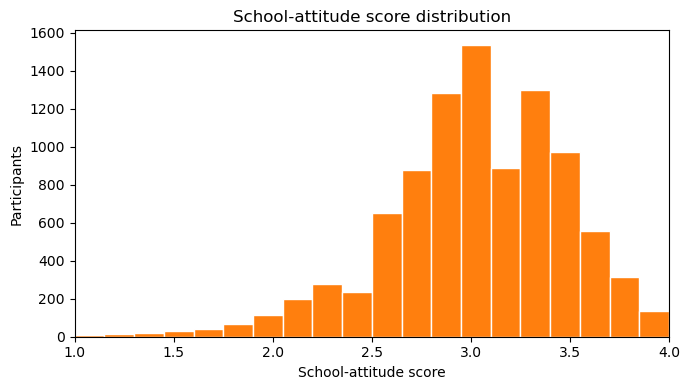

In [37]:
# 14: Plot the school-attitude score distribution

plt.figure(figsize=(7, 4))
plt.hist(
    predictor_matrix["school_attitude_score"].dropna(),
    bins=20,
    color="tab:orange",
    edgecolor="white",
)
plt.xlabel("School-attitude score")
plt.ylabel("Participants")
plt.title("School-attitude score distribution")
plt.xlim(1, 4)
plt.tight_layout()
plt.show()


### School-attitude score distribution

The school-attitude score distribution is plotted to assess spread, concentration and possible floor or ceiling effects within its constructed range.


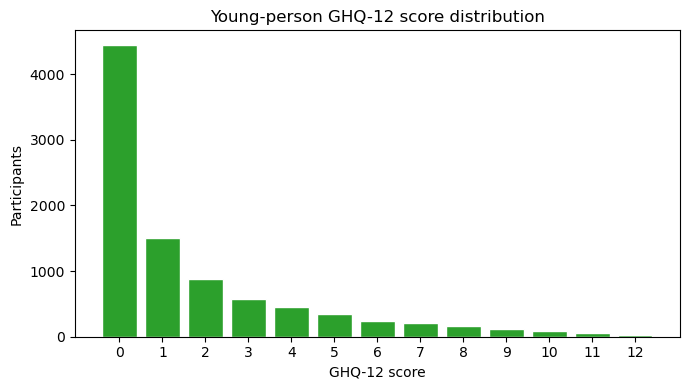

In [38]:
# 15: Plot the GHQ-12 score distribution

ghq12_counts = (
    predictor_matrix["young_person_ghq12_score"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(7, 4))
plt.bar(
    ghq12_counts.index,
    ghq12_counts.values,
    color="tab:green",
    edgecolor="white",
)
plt.xlabel("GHQ-12 score")
plt.ylabel("Participants")
plt.title("Young-person GHQ-12 score distribution")
plt.xticks(range(0, 13))
plt.tight_layout()
plt.show()


### Young-person GHQ-12 score distribution

The GHQ-12 distribution is plotted as a psychosocial predictor. The plot is used to inspect its observed score range and concentration; it is not interpreted as a clinical diagnosis.


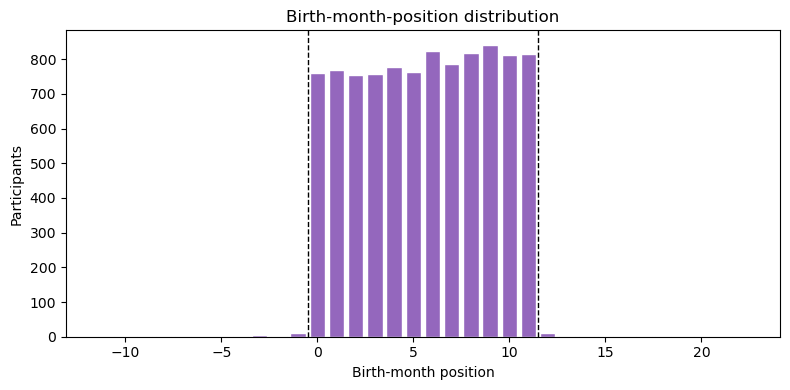

In [39]:
# 16: Plot the birth-month-position distribution

birth_position_counts = (
    predictor_matrix["birth_month_position"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 4))
plt.bar(
    birth_position_counts.index,
    birth_position_counts.values,
    color="tab:purple",
    edgecolor="white",
)
plt.axvline(-0.5, color="black", linestyle="--", linewidth=1)
plt.axvline(11.5, color="black", linestyle="--", linewidth=1)
plt.xlabel("Birth-month position")
plt.ylabel("Participants")
plt.title("Birth-month-position distribution")
plt.tight_layout()
plt.show()


### Birth-month-position distribution

The birth-month-position distribution is plotted because the derived measure can extend beyond the central 0–11 window. Values outside that window are reviewed in relation to the documented construction rather than treated automatically as invalid.


### Distribution plots

Plots are used for selected higher-cardinality predictors where frequency tables and summary ranges alone do not fully show concentration, skewness or edge values. Low-cardinality predictors are primarily assessed through category frequencies.


## Part 4: Predictor overlap and redundancy

Pairwise overlap is examined as a descriptive quality-control screen. Spearman correlations are calculated across numeric predictors, with caution where numerical codes represent nominal categories. Bias-corrected Cramér’s V is calculated for predictors with no more than ten observed values. A value of 0.80 is used to flag pairs for closer review, not as an automatic feature-removal threshold.


In [40]:
# 1: Calculate Spearman correlations between numeric predictors

spearman_matrix = predictor_matrix[numeric_predictors].corr(
    method="spearman",
    min_periods=500,
)

upper_rows, upper_columns = np.triu_indices_from(
    spearman_matrix,
    k=1,
)

correlation_pairs = pd.DataFrame({
    "Predictor 1": spearman_matrix.index[upper_rows],
    "Predictor 2": spearman_matrix.columns[upper_columns],
    "Spearman correlation": spearman_matrix.to_numpy()[
        upper_rows,
        upper_columns,
    ],
})

correlation_pairs["Absolute correlation"] = (
    correlation_pairs["Spearman correlation"].abs()
)

strong_correlations = (
    correlation_pairs
    .dropna(subset=["Spearman correlation"])
    .loc[lambda data: data["Absolute correlation"] >= 0.80]
    .sort_values("Absolute correlation", ascending=False)
    .reset_index(drop=True)
)

print(f"Unique numeric predictor pairs: {len(correlation_pairs):,}")
print(
    "Pairs with absolute Spearman correlation of at least 0.80:",
    len(strong_correlations),
)

display(strong_correlations.head(15))


Unique numeric predictor pairs: 2,080
Pairs with absolute Spearman correlation of at least 0.80: 0


,Predictor 1,Predictor 2,Spearman correlation,Absolute correlation


### Spearman correlation screen

Numeric predictor pairs are screened for strong monotonic overlap. The number of pairs is calculated from the 69-predictor set. Correlations involving numerically coded nominal predictors are not interpreted as ordered effects.

In [41]:
# 2: Inspect the strongest numeric-predictor correlations

top_correlations = (
    correlation_pairs
    .dropna(subset=["Spearman correlation"])
    .sort_values("Absolute correlation", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

display(top_correlations)


,Predictor 1,Predictor 2,Spearman correlation,Absolute correlation
0,household_income_band,working_parent_or_guardian_count,0.639753,0.639753
1,higher_education_application_likelihood,parental_higher_education_expectation_pretrans...,-0.625679,0.625679
2,highest_parental_qualification_code,family_nssec_code,0.581288,0.581288
3,family_nssec_code,household_income_band,-0.558571,0.558571
4,highest_parental_qualification_code,household_income_band,-0.537752,0.537752
5,disability_schooling_category,additional_parental_care_due_to_disability,-0.531653,0.531653
6,main_parent_disability,main_parent_general_health,0.524824,0.524824
7,smoking_activity_pretransition,cannabis_experience_pretransition,0.490290,0.490290
8,family_composition,working_parent_or_guardian_count,-0.455393,0.455393
9,family_future_study_discussion_frequency_pretr...,peer_future_study_discussion_frequency_pretran...,0.446785,0.446785


### Strongest Spearman correlations

The strongest observed numeric associations are displayed for substantive review. Related constructs may remain separate even when associated, so the screen does not impose global correlation pruning.


In [42]:
# 3: Identify predictors for categorical-association checks

categorical_like_predictors = [
    variable
    for variable in predictor_matrix.columns
    if variable != "NSID"
    and predictor_matrix[variable].nunique(dropna=True) <= 10
]

string_categorical_predictors = [
    variable
    for variable in categorical_like_predictors
    if pd.api.types.is_string_dtype(predictor_matrix[variable])
]

numeric_categorical_predictors = [
    variable
    for variable in categorical_like_predictors
    if variable not in string_categorical_predictors
]

print(
    "Predictors with no more than 10 observed values:",
    len(categorical_like_predictors)
)
print("String predictors:", len(string_categorical_predictors))
print("Numeric low-cardinality predictors:", len(numeric_categorical_predictors))


Predictors with no more than 10 observed values: 66
String predictors: 4
Numeric low-cardinality predictors: 62


### Predictors included in the Cramér’s V screen

Cramér’s V is applied to predictors with no more than ten observed values so that association can be assessed without relying on numeric code ordering. Higher-cardinality predictors are excluded from this screen.


In [43]:
# 4: Define bias-corrected Cramér's V

def corrected_cramers_v(first, second):
    # Use participants with observed values for both predictors
    complete = pd.DataFrame({
        "First": first,
        "Second": second,
    }).dropna()

    table = pd.crosstab(
        complete["First"],
        complete["Second"]
    )

    n = table.to_numpy().sum()
    rows, columns = table.shape

    if n <= 1 or rows < 2 or columns < 2:
        return np.nan

    chi_squared = chi2_contingency(
        table,
        correction=False
    )[0]

    phi_squared = chi_squared / n

    # Correct the association estimate for finite-sample bias
    corrected_phi_squared = max(
        0,
        phi_squared
        - ((columns - 1) * (rows - 1)) / (n - 1)
    )

    corrected_rows = rows - ((rows - 1) ** 2) / (n - 1)
    corrected_columns = columns - ((columns - 1) ** 2) / (n - 1)

    denominator = min(
        corrected_rows - 1,
        corrected_columns - 1
    )

    if denominator <= 0:
        return np.nan

    return np.sqrt(corrected_phi_squared / denominator)

print("Bias-corrected Cramér's V function defined.")

Bias-corrected Cramér's V function defined.


In [44]:
# 5: Calculate categorical associations between predictors

categorical_associations = []

# Assess each unique pair of low-cardinality predictors
for first, second in combinations(categorical_like_predictors, 2):
    complete_cases = predictor_matrix[[first, second]].dropna()

    categorical_associations.append({
        "Predictor 1": first,
        "Predictor 2": second,
        "Complete cases": len(complete_cases),
        "Corrected Cramér's V": corrected_cramers_v(
            predictor_matrix[first],
            predictor_matrix[second]
        ),
    })

categorical_associations = pd.DataFrame(categorical_associations)

valid_categorical_associations = categorical_associations.dropna(
    subset=["Corrected Cramér's V"]
)

# Retain pairs meeting the threshold for substantive review
strong_categorical_associations = (
    valid_categorical_associations[
        valid_categorical_associations["Corrected Cramér's V"] >= 0.80
    ]
    .sort_values("Corrected Cramér's V", ascending=False)
    .reset_index(drop=True)
)

print(f"Categorical predictor pairs assessed: {len(categorical_associations):,}")
print(
    "Pairs with corrected Cramér's V of at least 0.80:",
    len(strong_categorical_associations)
)

display(strong_categorical_associations.head(15))

print(
    "Pairs not displayed:",
    max(0, len(strong_categorical_associations) - 15)
)


Categorical predictor pairs assessed: 2,145
Pairs with corrected Cramér's V of at least 0.80: 0


,Predictor 1,Predictor 2,Complete cases,Corrected Cramér's V


Pairs not displayed: 0


### Cramér’s V redundancy screen

Low-cardinality predictor pairs are screened using bias-corrected Cramér’s V. Pairs at or above 0.80 are flagged for inspection, but substantive distinctions and predictor provenance determine whether any change is warranted.


In [45]:
# 6: Inspect the strongest categorical associations

top_categorical_associations = (
    categorical_associations
    .dropna(subset=["Corrected Cramér's V"])
    .sort_values("Corrected Cramér's V", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

display(top_categorical_associations)


,Predictor 1,Predictor 2,Complete cases,Corrected Cramér's V
0,ethnicity,non_english_home_language,9347,0.717498
1,disability_schooling_category,additional_parental_care_due_to_disability,9465,0.627304
2,sen_status_pretransition,current_statement_of_needs_pretransition,9625,0.570842
3,english_first_or_main_language,non_english_home_language,9349,0.566399
4,household_income_band,working_parent_or_guardian_count,8771,0.509785
5,smoking_activity_pretransition,cannabis_experience_pretransition,9502,0.498605
6,non_english_home_language,highest_parental_qualification_code,9338,0.472785
7,ethnicity,english_first_or_main_language,9514,0.466874
8,main_parent_disability,main_parent_general_health,9386,0.460815
9,non_english_home_language,alcohol_use_frequency_pretransition,9317,0.459327


### Strongest categorical associations

The strongest corrected Cramér’s V values are displayed to identify related categorical information. Cramér’s V measures association strength only and does not indicate direction or establish that two predictors are interchangeable.


In [46]:
# 7: Inspect ethnicity by home-language status

ethnicity_language_table = pd.crosstab(
    predictor_matrix["ethnicity"],
    predictor_matrix["non_english_home_language"],
    margins=True
)

ethnicity_language_percentages = (
    pd.crosstab(
        predictor_matrix["ethnicity"],
        predictor_matrix["non_english_home_language"],
        normalize="index"
    )
    * 100
).round(1)

print("Participant counts")
display(ethnicity_language_table)

print("Row percentages")
display(ethnicity_language_percentages)


Participant counts


non_english_home_language,0.0,1.0,All
ethnicity,,,
Bangladeshi,75,346,421
Black African,155,80,235
Black Caribbean,269,0,269
Indian,396,268,664
Mixed,432,13,445
Other,133,79,212
Pakistani,184,342,526
White,6536,39,6575
All,8180,1167,9347


Row percentages


non_english_home_language,0.0,1.0
ethnicity,,
Bangladeshi,17.8,82.2
Black African,66.0,34.0
Black Caribbean,100.0,0.0
Indian,59.6,40.4
Mixed,97.1,2.9
Other,62.7,37.3
Pakistani,35.0,65.0
White,99.4,0.6


### Ethnicity and non-English home-language use

The ethnicity by home-language table is inspected because these constructs can be strongly related while remaining substantively distinct. The final home-language predictor uses Wave 1 information only.


In [47]:
# 8: Compare the two language predictors

language_cross_table = pd.crosstab(
    predictor_matrix["english_first_or_main_language"],
    predictor_matrix["non_english_home_language"],
    margins=True
)

language_row_percentages = (
    pd.crosstab(
        predictor_matrix["english_first_or_main_language"],
        predictor_matrix["non_english_home_language"],
        normalize="index"
    )
    * 100
).round(1)

print("Participant counts")
display(language_cross_table)

print("Row percentages")
display(language_row_percentages)


Participant counts


non_english_home_language,0.0,1.0,All
english_first_or_main_language,,,
No,57,469,526
Yes,8125,698,8823
All,8182,1167,9349


Row percentages


non_english_home_language,0.0,1.0
english_first_or_main_language,,
No,10.8,89.2
Yes,92.1,7.9


### English-language measures

The two language measures are cross-tabulated to assess whether English first or main language and non-English home-language use capture overlapping but distinct aspects of language background.


## Predictor overlap findings

The overlap screens are interpreted as descriptive checks rather than automated feature selection. Exact duplicates would indicate a construction problem. High Spearman correlation or Cramér’s V would trigger substantive review, but correlated predictors are not removed solely because they measure related constructs. This is particularly important because later domain-level contribution analyses depend on preserving conceptually distinct pre-transition information.


## Part 5: EDA audit summary


In [48]:
# Stage 2 EDA summary

eda_summary = pd.DataFrame(
    [
        {
            "Participant rows": len(predictor_matrix),
            "Predictors": predictor_count,
            "Conceptual domains reviewed": len(conceptual_domains),
            "Represented domains": len(represented_domains),
            "Missing NSIDs": int(predictor_matrix["NSID"].isna().sum()),
            "Duplicated NSIDs": int(predictor_matrix["NSID"].duplicated().sum()),
            "Entirely missing predictors": len(entirely_missing),
            "Constant predictors": len(constant_predictors),
            "Exact duplicate predictor pairs": len(duplicate_pairs),
            "Infinite numeric values": int(infinite_counts.sum()),
            "Participants with five or fewer predictors": int(
                sample_support["five_or_fewer_predictors_available"].sum()
            ),
            "Spearman pairs at or above 0.80": len(strong_correlations),
            "Cramer's V pairs at or above 0.80": len(
                strong_categorical_associations
            ),
            "Outcome columns loaded": 0,
        }
    ]
)

display(eda_summary)

assert eda_summary.loc[0, "Participant rows"] == expected_participants
assert eda_summary.loc[0, "Predictors"] == expected_predictors
assert (
    eda_summary.loc[0, "Conceptual domains reviewed"]
    == expected_conceptual_domains
)
assert (
    eda_summary.loc[0, "Represented domains"]
    == expected_represented_domains
)
assert eda_summary.loc[0, "Missing NSIDs"] == 0
assert eda_summary.loc[0, "Duplicated NSIDs"] == 0
assert eda_summary.loc[0, "Entirely missing predictors"] == 0
assert eda_summary.loc[0, "Constant predictors"] == 0
assert eda_summary.loc[0, "Exact duplicate predictor pairs"] == 0
assert eda_summary.loc[0, "Infinite numeric values"] == 0

print("Structural EDA checks: PASS")
print(
    "Association screens are descriptive and do not automatically "
    "remove predictors."
)


,Participant rows,Predictors,Conceptual domains reviewed,Represented domains,Missing NSIDs,Duplicated NSIDs,Entirely missing predictors,Constant predictors,Exact duplicate predictor pairs,Infinite numeric values,Participants with five or fewer predictors,Spearman pairs at or above 0.80,Cramer's V pairs at or above 0.80,Outcome columns loaded
0,9767,69,11,10,0,0,0,0,0,0,243,0,0,0


Structural EDA checks: PASS
Association screens are descriptive and do not automatically remove predictors.


# EDA interpretation note

This notebook evaluates the Stage 2 predictor matrix without loading the age-18 outcome. Missingness, distribution and overlap checks identify data-quality or representation issues before modelling. Ordinary missing values are retained, preprocessing is deferred until after data partitioning, and association screens do not by themselves justify removing conceptually distinct predictors. The modelling-sample decision for participants with structural early-wave coverage gaps is made after predictor and outcome data are combined.